<a href="https://colab.research.google.com/github/sidharth2733mba25fin-ops/AI-finance-expense-automation-system/blob/main/Lab_7_8_Transparency_Auditing_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7–8: Transparency Auditing in AI Decision-Making

## Domain: AI-Based Loan Approval System

### Lab Objective
In this lab, we will understand how to audit an AI decision system for transparency.

Transparency auditing means checking whether an AI system clearly shows:
- What data is being used
- Which features influence decisions
- Whether decision reasons are understandable
- Whether customers and managers can receive clear explanations
- Whether the system creates governance and trust risks

This lab uses a synthetic loan approval dataset for learning purposes.


In [ ]:
# ============================================================
# Cell 1: Import Required Libraries
# ============================================================

# pandas is used to create and analyze tabular data.
import pandas as pd

# numpy is used for numerical operations.
import numpy as np

# matplotlib is used for visualizations.
import matplotlib.pyplot as plt

# sklearn is used for building a simple machine learning model.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
# ============================================================
# Cell 2: Create Synthetic Loan Approval Dataset
# ============================================================

# This is a synthetic dataset created for classroom learning.
# It does not contain any real customer data.

# We are simulating a loan approval system where applicants are evaluated
# using financial features such as income, credit score, EMI burden,
# employment stability, and debt ratio.

data = {
    "Applicant_ID": range(1, 31),

    # Annual income in lakhs
    "Income_Lakhs": [
        4, 5, 6, 7, 8, 9, 10, 12, 15, 18,
        3, 4, 5, 7, 8, 10, 11, 13, 16, 20,
        6, 7, 9, 11, 14, 5, 8, 12, 15, 19
    ],

    # Credit score out of 900
    "Credit_Score": [
        610, 640, 660, 690, 720, 740, 760, 780, 810, 840,
        590, 620, 650, 680, 710, 750, 770, 790, 820, 850,
        630, 670, 730, 760, 800, 600, 700, 775, 815, 845
    ],

    # Existing EMI burden in thousands
    "Existing_EMI_Thousands": [
        25, 22, 20, 18, 15, 14, 12, 10, 8, 6,
        28, 24, 21, 19, 16, 13, 12, 9, 7, 5,
        23, 18, 14, 11, 9, 26, 17, 10, 8, 6
    ],

    # Debt-to-income ratio
    # Higher value means higher financial burden.
    "Debt_to_Income_Ratio": [
        0.55, 0.50, 0.46, 0.42, 0.36, 0.32, 0.28, 0.24, 0.20, 0.16,
        0.60, 0.53, 0.48, 0.43, 0.38, 0.30, 0.27, 0.22, 0.18, 0.14,
        0.52, 0.44, 0.34, 0.29, 0.21, 0.58, 0.40, 0.25, 0.19, 0.15
    ],

    # Employment stability in years
    "Employment_Stability_Years": [
        1, 1, 2, 2, 3, 4, 5, 6, 8, 10,
        1, 1, 2, 3, 4, 5, 5, 7, 9, 11,
        2, 3, 4, 5, 8, 1, 3, 6, 8, 10
    ],

    # Final loan decision
    # 1 = Approved
    # 0 = Rejected
    "Loan_Approved": [
        0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 0, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

# Display the dataset
df


,Applicant_ID,Income_Lakhs,Credit_Score,Existing_EMI_Thousands,Debt_to_Income_Ratio,Employment_Stability_Years,Loan_Approved
0,1,4,610,25,0.55,1,0
1,2,5,640,22,0.50,1,0
2,3,6,660,20,0.46,2,0
3,4,7,690,18,0.42,2,1
4,5,8,720,15,0.36,3,1
5,6,9,740,14,0.32,4,1
6,7,10,760,12,0.28,5,1
7,8,12,780,10,0.24,6,1
8,9,15,810,8,0.20,8,1
9,10,18,840,6,0.16,10,1


In [ ]:
# ============================================================
# Cell 3: Understand Dataset Structure
# ============================================================

# Transparency starts with understanding the dataset.
# We first check column names, data types, and missing values.

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (30, 7)

Column Names:
['Applicant_ID', 'Income_Lakhs', 'Credit_Score', 'Existing_EMI_Thousands', 'Debt_to_Income_Ratio', 'Employment_Stability_Years', 'Loan_Approved']

Data Types:
Applicant_ID                    int64
Income_Lakhs                    int64
Credit_Score                    int64
Existing_EMI_Thousands          int64
Debt_to_Income_Ratio          float64
Employment_Stability_Years      int64
Loan_Approved                   int64
dtype: object

Missing Values:
Applicant_ID                  0
Income_Lakhs                  0
Credit_Score                  0
Existing_EMI_Thousands        0
Debt_to_Income_Ratio          0
Employment_Stability_Years    0
Loan_Approved                 0
dtype: int64


In [ ]:
# ============================================================
# Cell 4: Create Input Features and Target Variable
# ============================================================

# In machine learning:
# X contains input features used for prediction.
# y contains the target variable that the model tries to predict.

# We exclude Applicant_ID because it is only an identifier.
# We also exclude Loan_Approved from X because that is the answer.

X = df.drop(columns=["Applicant_ID", "Loan_Approved"])
y = df["Loan_Approved"]

print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())


Input Features:
   Income_Lakhs  Credit_Score  Existing_EMI_Thousands  Debt_to_Income_Ratio  \
0             4           610                      25                  0.55   
1             5           640                      22                  0.50   
2             6           660                      20                  0.46   
3             7           690                      18                  0.42   
4             8           720                      15                  0.36   

   Employment_Stability_Years  
0                           1  
1                           1  
2                           2  
3                           2  
4                           3  

Target Variable:
0    0
1    0
2    0
3    1
4    1
Name: Loan_Approved, dtype: int64


In [ ]:
# ============================================================
# Cell 5: Split Data into Training and Testing Sets
# ============================================================

# Training data is used to teach the model.
# Testing data is used to check model performance on unseen data.

# random_state is used so that results remain the same every time.
# stratify=y ensures both approved and rejected examples are balanced
# in train and test split as much as possible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])


Training Rows: 21
Testing Rows: 9


In [ ]:
# ============================================================
# Cell 6: Train a Transparent Decision Tree Model
# ============================================================

# We use a Decision Tree because it is easier to explain than
# complex black-box models.

# max_depth=3 keeps the tree small and interpretable.
# A deeper tree may give better accuracy but can become harder to explain.

model = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


In [ ]:
# ============================================================
# Cell 7: Evaluate Model Performance
# ============================================================

# Accuracy tells us how many predictions were correct.
# But transparency auditing is not only about accuracy.
# We also need to understand WHY decisions were made.

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



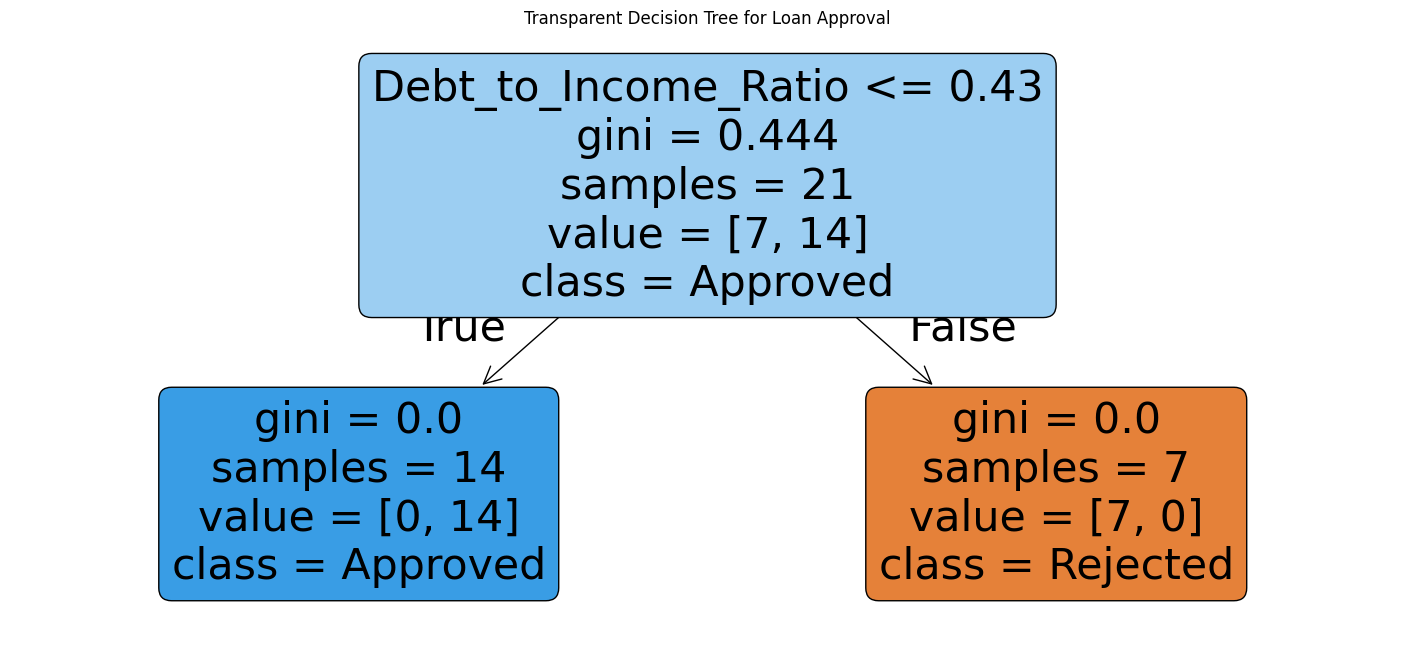

In [ ]:
# ============================================================
# Cell 8: Visualize the Decision Tree
# ============================================================

# This visualization helps us see how the model makes decisions.
# Each node shows a condition such as Credit_Score <= 695.
# This makes the model more transparent than a black-box model.

plt.figure(figsize=(18, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True
)

plt.title("Transparent Decision Tree for Loan Approval")
plt.show()


In [ ]:
# ============================================================
# Cell 9: Feature Importance Audit
# ============================================================

# Feature importance shows which variables influenced the model most.
# This helps managers understand whether the model is relying on sensible features.

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
3,Debt_to_Income_Ratio,1.0
0,Income_Lakhs,0.0
1,Credit_Score,0.0
2,Existing_EMI_Thousands,0.0
4,Employment_Stability_Years,0.0


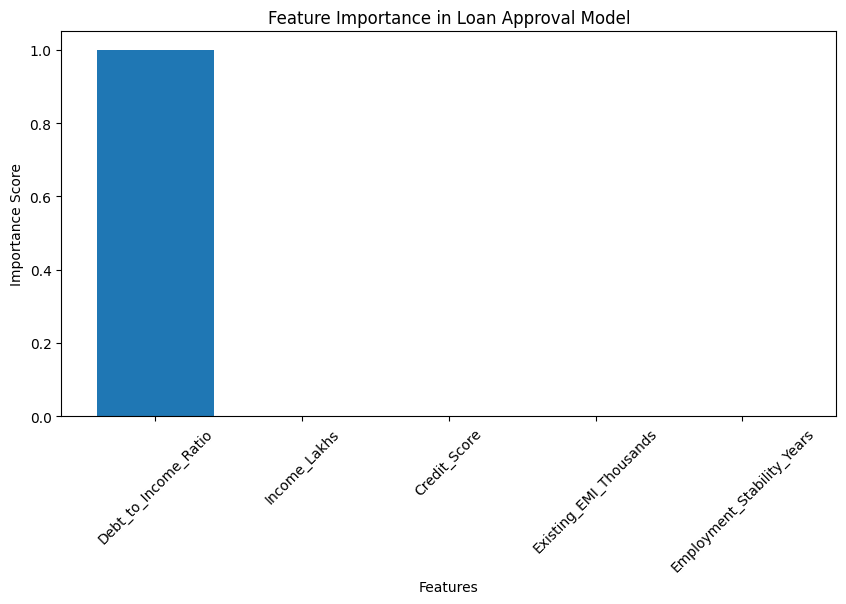

In [ ]:
# ============================================================
# Cell 10: Visualize Feature Importance
# ============================================================

# A bar chart makes it easier to understand which features matter most.

plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance in Loan Approval Model")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.show()


In [ ]:
# ============================================================
# Cell 11: Create Customer-Friendly Reason Codes
# ============================================================

# In real finance, customers should not receive vague answers like:
# "Your model score is low."
#
# Instead, they should receive understandable reason codes such as:
# "Credit score is below preferred threshold"
# "Debt-to-income ratio is high"
# "Existing EMI burden is high"

def generate_reason_code(row):
    reasons = []

    if row["Credit_Score"] < 700:
        reasons.append("Credit score is below preferred threshold")

    if row["Debt_to_Income_Ratio"] > 0.40:
        reasons.append("Debt-to-income ratio is high")

    if row["Existing_EMI_Thousands"] > 18:
        reasons.append("Existing EMI burden is high")

    if row["Employment_Stability_Years"] < 2:
        reasons.append("Employment stability is low")

    if row["Income_Lakhs"] < 6:
        reasons.append("Income is below preferred level")

    if len(reasons) == 0:
        reasons.append("Financial profile meets major eligibility indicators")

    return "; ".join(reasons)

df["Reason_Code"] = df.apply(generate_reason_code, axis=1)

df[["Applicant_ID", "Loan_Approved", "Reason_Code"]]


,Applicant_ID,Loan_Approved,Reason_Code
0,1,0,Credit score is below preferred threshold; Deb...
1,2,0,Credit score is below preferred threshold; Deb...
2,3,0,Credit score is below preferred threshold; Deb...
3,4,1,Credit score is below preferred threshold; Deb...
4,5,1,Financial profile meets major eligibility indi...
5,6,1,Financial profile meets major eligibility indi...
6,7,1,Financial profile meets major eligibility indi...
7,8,1,Financial profile meets major eligibility indi...
8,9,1,Financial profile meets major eligibility indi...
9,10,1,Financial profile meets major eligibility indi...


In [ ]:
# ============================================================
# Cell 12: Transparency Audit Checklist
# ============================================================

# This checklist helps managers audit whether the AI system is transparent.

audit_checklist = pd.DataFrame({
    "Audit Question": [
        "Are all input features clearly documented?",
        "Can the model decision be explained in simple language?",
        "Are customer-friendly reason codes available?",
        "Can managers see which features influence decisions?",
        "Is the model simple enough for business users to understand?",
        "Are missing values checked?",
        "Is there a process for human review?",
        "Are decisions regularly monitored?"
    ],
    "Status": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Partially",
        "Yes",
        "Needs Business Policy",
        "Needs Ongoing Monitoring"
    ]
})

audit_checklist


,Audit Question,Status
0,Are all input features clearly documented?,Yes
1,Can the model decision be explained in simple ...,Yes
2,Are customer-friendly reason codes available?,Yes
3,Can managers see which features influence deci...,Yes
4,Is the model simple enough for business users ...,Partially
5,Are missing values checked?,Yes
6,Is there a process for human review?,Needs Business Policy
7,Are decisions regularly monitored?,Needs Ongoing Monitoring


In [ ]:
# ============================================================
# Cell 13: Identify Potential Transparency Risks
# ============================================================

# Even if a model is accurate, it may still create transparency risks.
# Here we list risks that managers should discuss.

transparency_risks = [
    "Customers may not understand why their loan was rejected.",
    "Managers may over-trust the model without checking feature logic.",
    "A complex model may improve accuracy but reduce explainability.",
    "Reason codes may oversimplify the actual model logic.",
    "Model performance may change over time due to economic conditions.",
    "If data sources are not documented, audit quality becomes weak."
]

for i, risk in enumerate(transparency_risks, start=1):
    print(f"{i}. {risk}")


1. Customers may not understand why their loan was rejected.
2. Managers may over-trust the model without checking feature logic.
3. A complex model may improve accuracy but reduce explainability.
4. Reason codes may oversimplify the actual model logic.
5. Model performance may change over time due to economic conditions.
6. If data sources are not documented, audit quality becomes weak.


In [ ]:
# ============================================================
# Cell 14: Managerial Interpretation
# ============================================================

print("""
Managerial Interpretation:

This lab shows that transparency auditing is not only a technical activity.
It is also a governance and trust-building activity.

A finance manager should ask:
1. What data is the AI system using?
2. Are the features financially meaningful?
3. Can the decision be explained to customers?
4. Can the model be defended before auditors and regulators?
5. Is there a human review process for borderline cases?

A transparent AI system helps reduce customer confusion,
regulatory risk, reputational damage, and internal governance failure.
""")



Managerial Interpretation:

This lab shows that transparency auditing is not only a technical activity.
It is also a governance and trust-building activity.

A finance manager should ask:
1. What data is the AI system using?
2. Are the features financially meaningful?
3. Can the decision be explained to customers?
4. Can the model be defended before auditors and regulators?
5. Is there a human review process for borderline cases?

A transparent AI system helps reduce customer confusion,
regulatory risk, reputational damage, and internal governance failure.



In [ ]:
# ============================================================
# Cell 15: Student Reflection Questions
# ============================================================

reflection_questions = [
    "1. Why is transparency important in AI-based loan decisions?",
    "2. What is the difference between model accuracy and model explainability?",
    "3. Why is a Decision Tree easier to explain than a black-box model?",
    "4. What are reason codes, and why are they useful?",
    "5. Can a highly accurate model still be ethically risky?",
    "6. What should a manager do if customers complain that AI decisions are unclear?",
    "7. Why should AI systems be audited regularly?",
    "8. How does transparency protect company reputation?"
]

for question in reflection_questions:
    print(question)


1. Why is transparency important in AI-based loan decisions?
2. What is the difference between model accuracy and model explainability?
3. Why is a Decision Tree easier to explain than a black-box model?
4. What are reason codes, and why are they useful?
5. Can a highly accurate model still be ethically risky?
6. What should a manager do if customers complain that AI decisions are unclear?
7. Why should AI systems be audited regularly?
8. How does transparency protect company reputation?


In [ ]:
# ============================================================
# Cell 16: Lab Conclusion
# ============================================================

print("""
Lab Conclusion:

In this lab, we performed a basic transparency audit of an AI-based loan approval system.

We learned that responsible AI is not only about prediction accuracy.
It also requires:
- Clear data documentation
- Understandable decision logic
- Feature importance analysis
- Customer-friendly explanations
- Reason codes
- Human oversight
- Ongoing monitoring

Key Learning:
If an organization cannot explain an important AI decision,
it may not be able to defend that decision before customers,
regulators, auditors, media, or its own leadership team.
""")



Lab Conclusion:

In this lab, we performed a basic transparency audit of an AI-based loan approval system.

We learned that responsible AI is not only about prediction accuracy.
It also requires:
- Clear data documentation
- Understandable decision logic
- Feature importance analysis
- Customer-friendly explanations
- Reason codes
- Human oversight
- Ongoing monitoring

Key Learning:
If an organization cannot explain an important AI decision,
it may not be able to defend that decision before customers,
regulators, auditors, media, or its own leadership team.

